In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("NewAncientTemples.csv")
print("Data set info:")
print(df.info())

print("-" * 50)
print("summary statistics:")
print(df.describe())

Data set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   templeName                53 non-null     object 
 1   Description               53 non-null     object 
 2   Location                  52 non-null     object 
 3   Coordinates               53 non-null     object 
 4   DistanceFromMumbai(Km)    53 non-null     float64
 5   DistanceFromNewDelhi(Km)  53 non-null     float64
 6   DistanceFromChennai(Km)   53 non-null     float64
 7   DistanceFromKolkata(Km)   53 non-null     float64
dtypes: float64(4), object(4)
memory usage: 3.4+ KB
None
--------------------------------------------------
summary statistics:
       DistanceFromMumbai(Km)  DistanceFromNewDelhi(Km)  \
count               53.000000                 53.000000   
mean              1195.137153               1141.181755   
std                844.27663

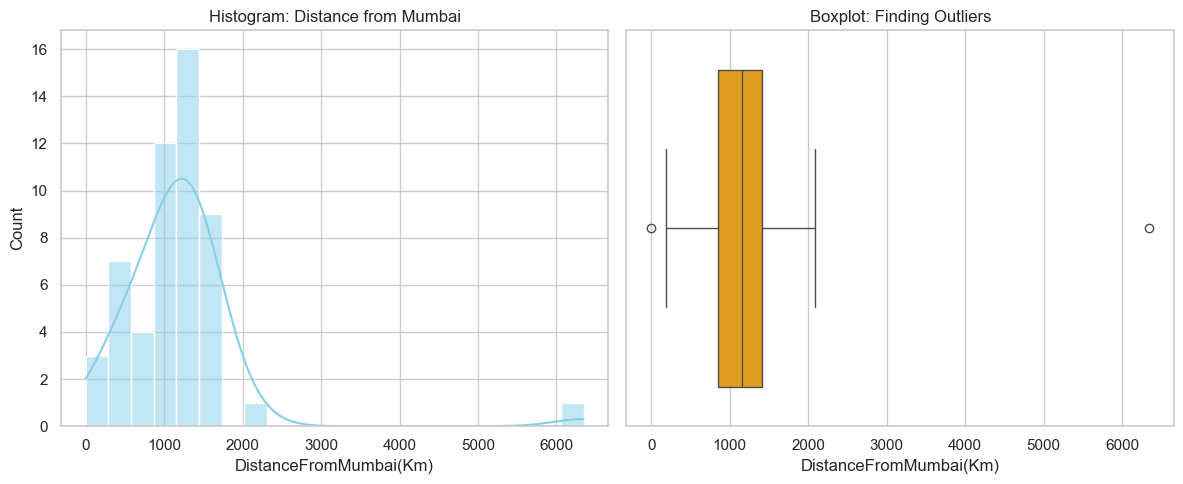

In [3]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['DistanceFromMumbai(Km)'], kde=True, color='skyblue')
plt.title("Histogram: Distance from Mumbai")

plt.subplot(1,2,2)
sns.boxplot(x=df['DistanceFromMumbai(Km)'], color='orange')
plt.title("Boxplot: Finding Outliers")

plt.tight_layout()
plt.show()

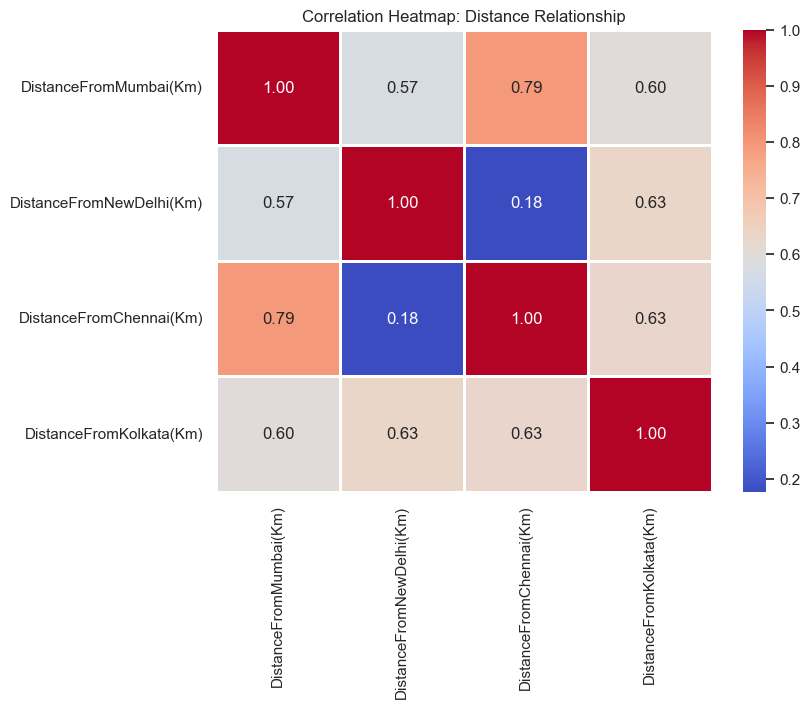

In [5]:
numeric_columns = df[['DistanceFromMumbai(Km)', 'DistanceFromNewDelhi(Km)', 
                      'DistanceFromChennai(Km)', 'DistanceFromKolkata(Km)']]
corr_matrix = numeric_columns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

plt.title("Correlation Heatmap: Distance Relationship")
plt.show()

In [6]:
outlier_temple = df[df['DistanceFromMumbai(Km)'] > 7000]
print("Outlier detected:")
print(outlier_temple[['templeName', 'Location', 'DistanceFromMumbai(Km)']])

Outlier detected:
Empty DataFrame
Columns: [templeName, Location, DistanceFromMumbai(Km)]
Index: []


In [8]:
outliers = df[(df['DistanceFromMumbai(Km)'] > 6000) | 
              (df['DistanceFromChennai(Km)'] > 6000)]
print("--- 🚨 The REAL Outliers 🚨 ---")
print(outliers[['templeName', 'Location', 'DistanceFromMumbai(Km)', 'DistanceFromChennai(Km)']])

--- 🚨 The REAL Outliers 🚨 ---
                   templeName Location  DistanceFromMumbai(Km)  \
17  Konark Sun Temple, Orissa      NaN             6345.522996   

    DistanceFromChennai(Km)  
17               7374.45296  
